#### DML

In [4]:
import pyreadr
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LassoCV, LogisticRegressionCV

from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDMulti

In [16]:
# retirar os warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
# download file from did package for R
url = "https://github.com/bcallaway11/did/raw/refs/heads/master/data/mpdta.rda"
pyreadr.download_file(url, "mpdta.rda")

mpdta = pyreadr.read_r("mpdta.rda")["mpdta"]
mpdta.head()

,year,countyreal,lpop,lemp,first.treat,treat
0,2003,8001.0,5.896761,8.461469,2007.0,1.0
1,2004,8001.0,5.896761,8.336870,2007.0,1.0
2,2005,8001.0,5.896761,8.340217,2007.0,1.0
3,2006,8001.0,5.896761,8.378161,2007.0,1.0
4,2007,8001.0,5.896761,8.487352,2007.0,1.0


In [6]:
# Set values for treatment group indicator for never-treated to np.inf
mpdta.loc[mpdta['first.treat'] == 0, 'first.treat'] = np.inf

dml_data = DoubleMLPanelData(
    data=mpdta,
    y_col="lemp",
    d_cols="first.treat",
    id_col="countyreal",
    t_col="year",
    x_cols=['lpop']
)
print(dml_data)

================== DoubleMLPanelData Object ==================

------------------ Data summary      ------------------
Outcome variable: lemp
Treatment variable(s): ['first.treat']
Covariates: ['lpop']
Instrument variable(s): None
Time variable: year
Id variable: countyreal
No. Observations: 500

------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Columns: 6 entries, year to treat
dtypes: float64(5), int32(1)
memory usage: 107.5 KB



In [7]:
dml_obj = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=DummyRegressor(),
    ml_m=DummyClassifier(),
    control_group="never_treated",
    n_folds=10
)

dml_obj.fit()
print(dml_obj.summary.round(4))

                         coef  std err       t   P>|t|   2.5 %  97.5 %
ATT(2004.0,2003,2004) -0.0105   0.0231 -0.4544  0.6495 -0.0559  0.0348
ATT(2004.0,2003,2005) -0.0704   0.0310 -2.2710  0.0231 -0.1312 -0.0096
ATT(2004.0,2003,2006) -0.1373   0.0369 -3.7216  0.0002 -0.2096 -0.0650
ATT(2004.0,2003,2007) -0.1008   0.0344 -2.9279  0.0034 -0.1683 -0.0333
ATT(2006.0,2003,2004)  0.0065   0.0234  0.2797  0.7797 -0.0392  0.0523
ATT(2006.0,2004,2005) -0.0027   0.0195 -0.1405  0.8883 -0.0410  0.0355
ATT(2006.0,2005,2006) -0.0046   0.0180 -0.2547  0.7989 -0.0399  0.0307
ATT(2006.0,2005,2007) -0.0412   0.0203 -2.0292  0.0424 -0.0810 -0.0014
ATT(2007.0,2003,2004)  0.0306   0.0151  2.0323  0.0421  0.0011  0.0601
ATT(2007.0,2004,2005) -0.0028   0.0164 -0.1686  0.8661 -0.0350  0.0294
ATT(2007.0,2005,2006) -0.0311   0.0180 -1.7316  0.0834 -0.0663  0.0041
ATT(2007.0,2006,2007) -0.0260   0.0167 -1.5582  0.1192 -0.0587  0.0067


c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\d

In [8]:
level = 0.95

ci = dml_obj.confint(level=level)
dml_obj.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj.confint(level=level, joint=True)
print(ci_joint)

                          2.5 %    97.5 %
ATT(2004.0,2003,2004) -0.074897  0.053868
ATT(2004.0,2003,2005) -0.156699  0.015862
ATT(2004.0,2003,2006) -0.239929 -0.034643
ATT(2004.0,2003,2007) -0.196574 -0.005003
ATT(2006.0,2003,2004) -0.058449  0.071513
ATT(2006.0,2004,2005) -0.057011  0.051531
ATT(2006.0,2005,2006) -0.054685  0.045512
ATT(2006.0,2005,2007) -0.097669  0.015290
ATT(2007.0,2003,2004) -0.011297  0.072508
ATT(2007.0,2004,2005) -0.048492  0.042952
ATT(2007.0,2005,2006) -0.081109  0.018884
ATT(2007.0,2006,2007) -0.072408  0.020423


c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


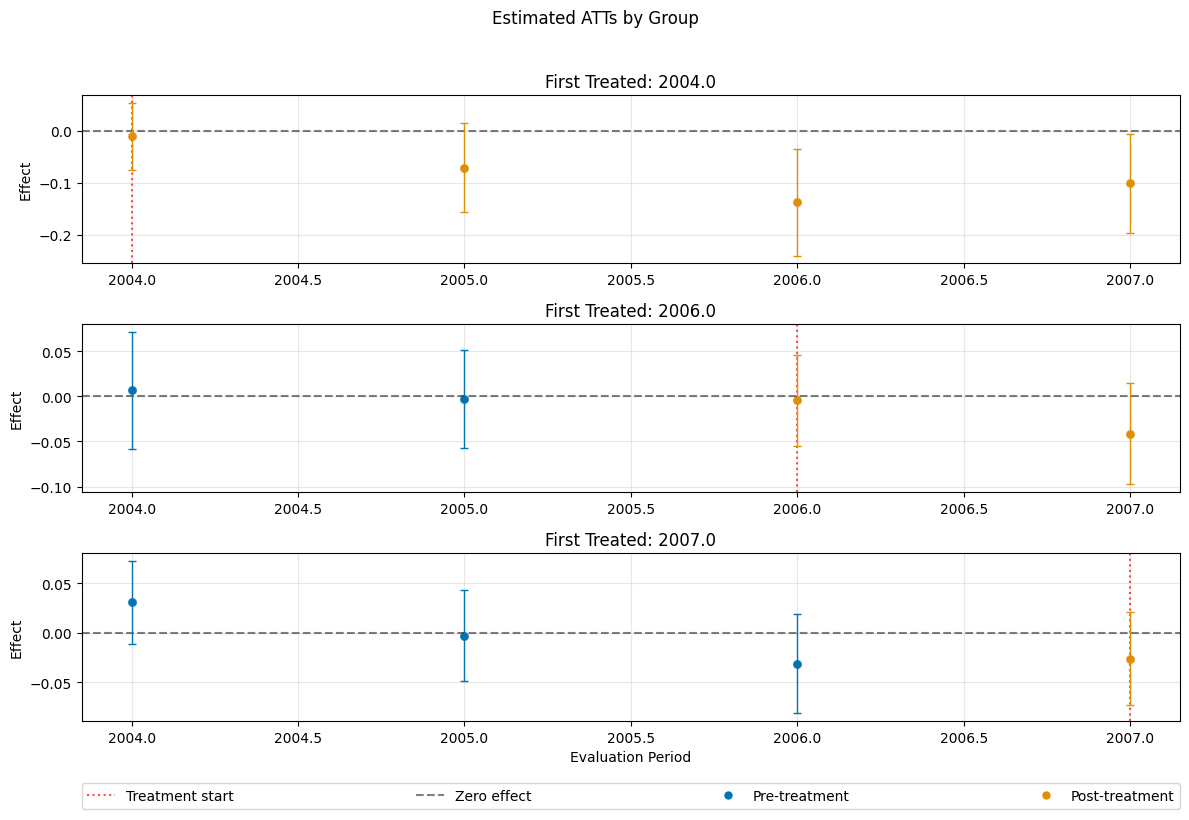

In [9]:
fig, ax = dml_obj.plot_effects()

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
     coef  std err         t    P>|t|     2.5 %    97.5 %
-0.077224 0.020063 -3.849147 0.000119 -0.116546 -0.037902
------------------ Aggregated Effects         ------------------
          coef   std err         t     P>|t|     2.5 %    97.5 %
-3.0  0.030606  0.015059  2.032335  0.042120  0.001090  0.060121
-2.0 -0.000594  0.013314 -0.044634  0.964399 -0.026690  0.025502
-1.0 -0.024476  0.014266 -1.715717  0.086214 -0.052436  0.003484
0.0  -0.019889  0.011834 -1.680627  0.092835 -0.043084  0.003306
1.0  -0.050933  0.016841 -3.024286  0.002492 -0.083941 -0.017924
2.0  -0.137286  0.036888 -3.721641  0.000198 -0.209586 -0.064986
3.0  -0.100789  0.034424 -2.927866  0.003413 -0.168258 -0.033319
------------------ Additional Information     ------------------
Score function: observational
Control group: never_treated
Anticipation pe

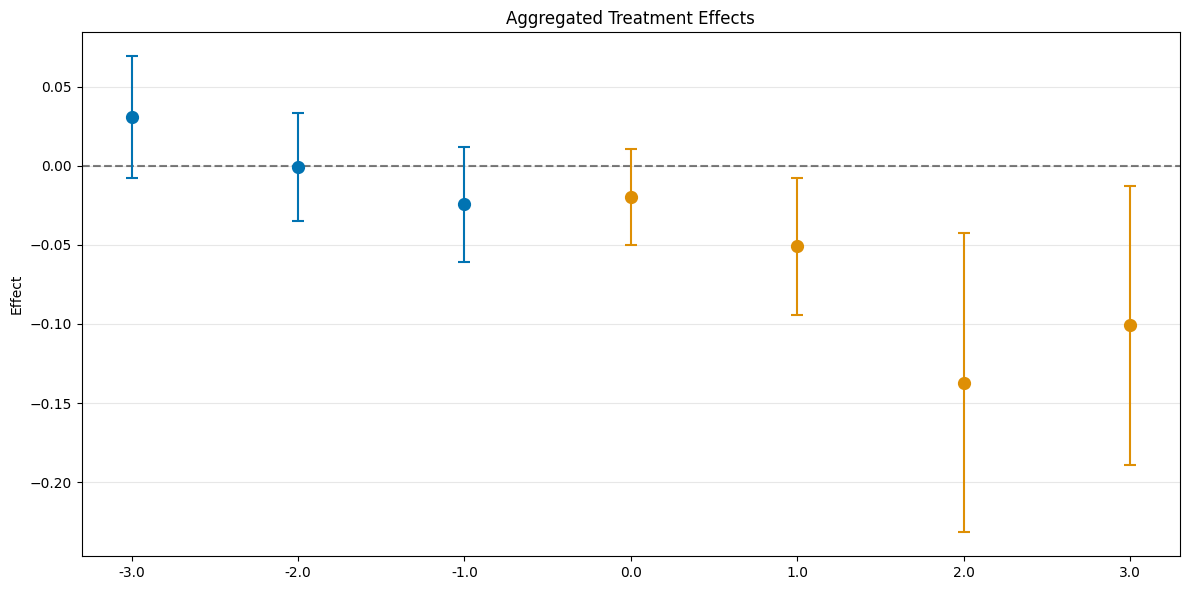

In [10]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj.bootstrap(n_rep_boot=5000)
aggregated_eventstudy = dml_obj.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy)
fig, ax = aggregated_eventstudy.plot_effects()

In [11]:
aggregated_eventstudy.aggregation_weights[2]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.23391813, 0.        , 0.        , 0.        , 0.        ,
       0.76608187, 0.        ])

c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\d

(<Figure size 1200x800 with 4 Axes>,
 [<Axes: title={'center': 'First Treated: 2004.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2006.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2007.0'}, xlabel='Evaluation Period', ylabel='Effect'>])

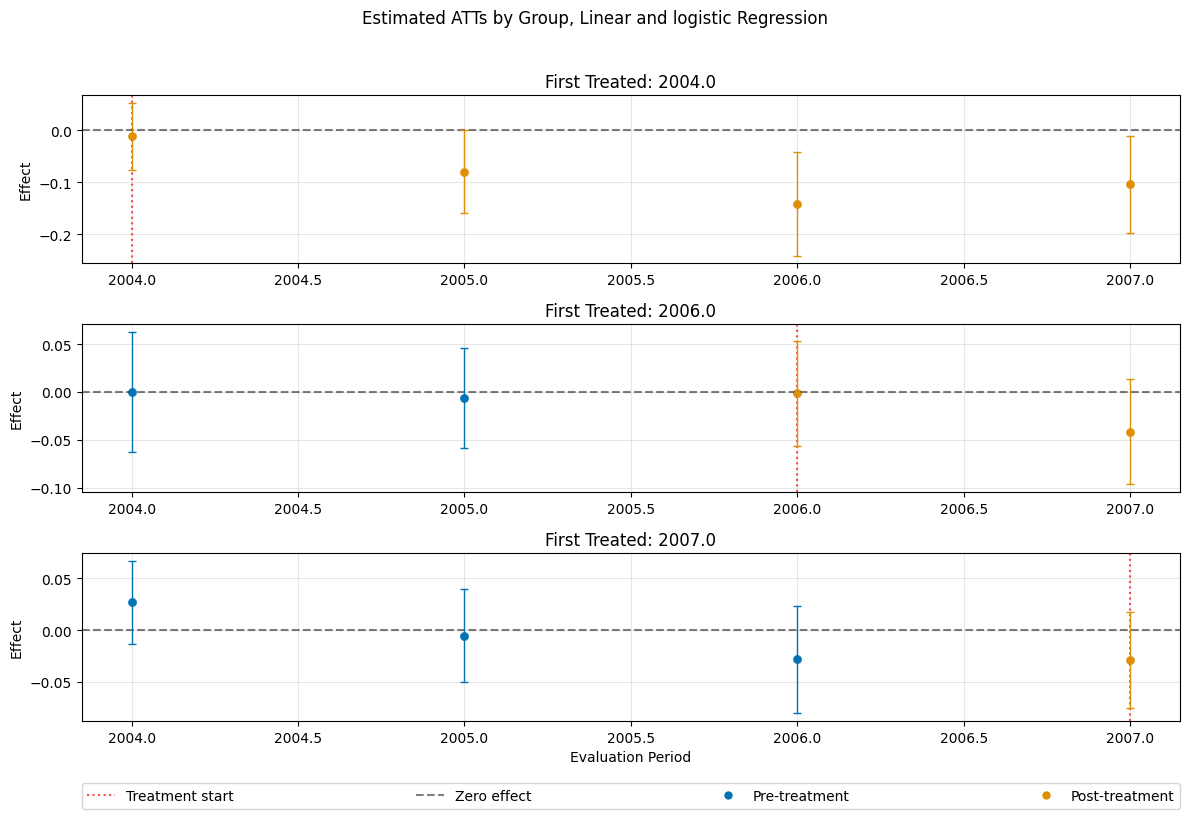

In [12]:
dml_obj_linear_logistic = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=LinearRegression(),
    ml_m=LogisticRegression(penalty=None),
    control_group="never_treated",
    n_folds=10
)

dml_obj_linear_logistic.fit()
dml_obj_linear_logistic.bootstrap(n_rep_boot=5000)
dml_obj_linear_logistic.plot_effects(title="Estimated ATTs by Group, Linear and logistic Regression")

In [13]:
print(dml_obj_linear_logistic)

================== DoubleMLDIDMulti Object ==================

------------------ Data summary      ------------------
Outcome variable: lemp
Treatment variable(s): ['first.treat']
Covariates: ['lpop']
Instrument variable(s): None
Time variable: year
Id variable: countyreal
No. Observations: 500

------------------ Score & algorithm ------------------
Score function: observational
Control group: never_treated
Anticipation periods: 0

------------------ Machine learner   ------------------
Learner ml_g: LinearRegression()
Learner ml_m: LogisticRegression(penalty=None)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[0.17205545 0.18211418 0.25862398 0.25782584 0.17168731 0.15237889
  0.20106251 0.20674602 0.17195637 0.15252302 0.20146193 0.16363372]]
Learner ml_g1 RMSE: [[0.10518153 0.12788043 0.14243423 0.14856048 0.14009704 0.11262819
  0.08682466 0.10402307 0.13728099 0.1621841  0.16306904 0.16212969]]
Classification:
Learner ml_m Log Loss: [[0.22949191 0.22946635 0.229561

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Estimated ATTs by Group, Linear and logistic Regression'}, ylabel='Effect'>)

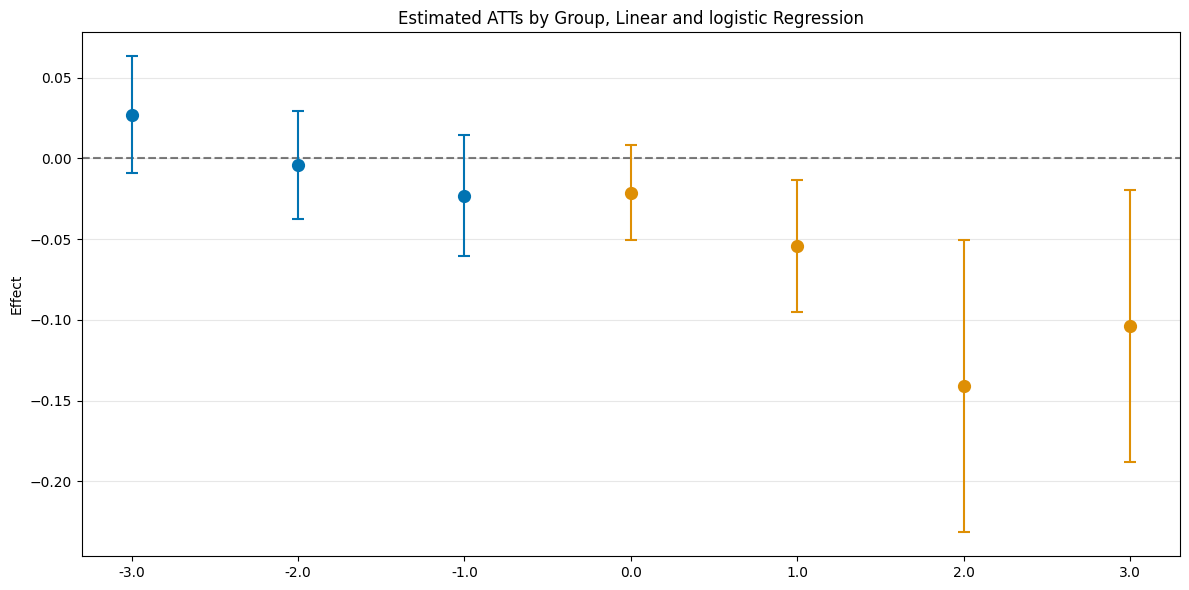

In [14]:
es_linear_logistic = dml_obj_linear_logistic.aggregate("eventstudy")
es_linear_logistic.aggregated_frameworks.bootstrap()
es_linear_logistic.plot_effects(title="Estimated ATTs by Group, Linear and logistic Regression")

(<Figure size 1200x800 with 4 Axes>,
 [<Axes: title={'center': 'First Treated: 2004.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2006.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2007.0'}, xlabel='Evaluation Period', ylabel='Effect'>])

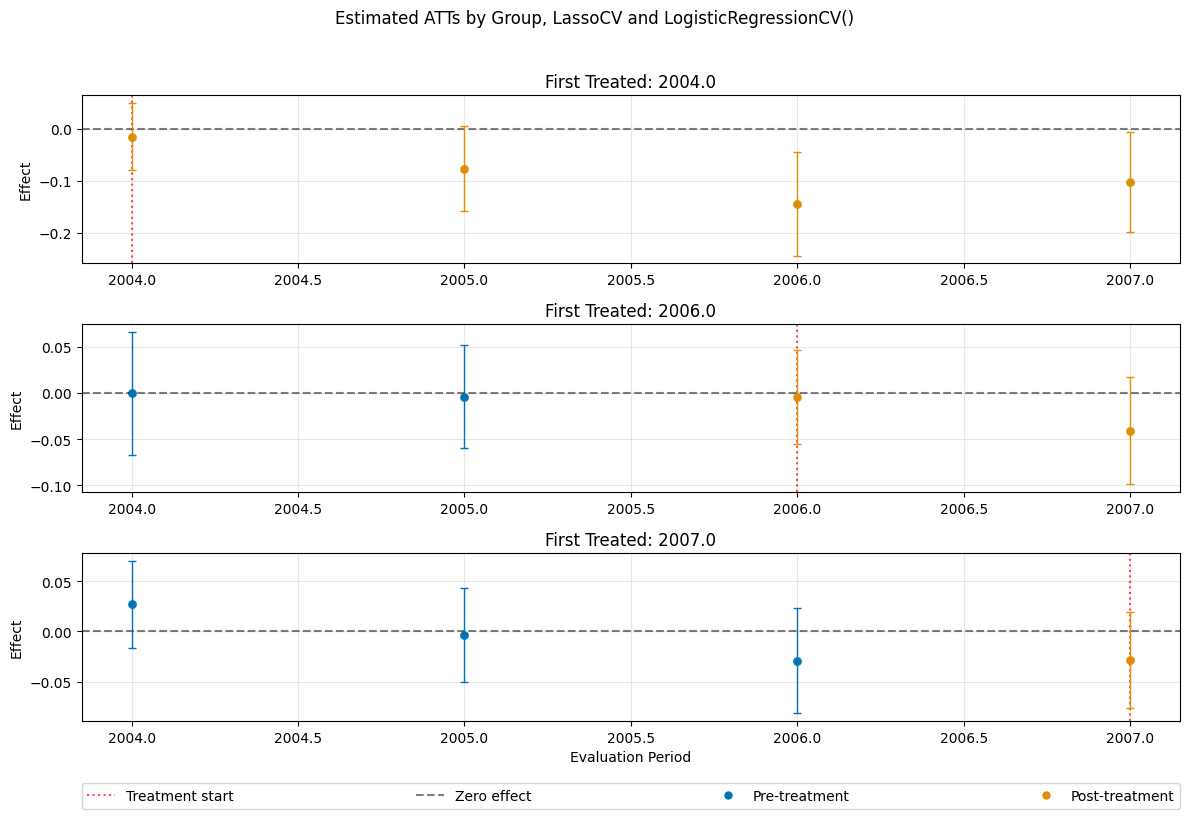

In [17]:
dml_obj_lasso = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=LassoCV(),
    ml_m=LogisticRegressionCV(),
    control_group="never_treated",
    n_folds=10
)

dml_obj_lasso.fit()
dml_obj_lasso.bootstrap(n_rep_boot=5000)
dml_obj_lasso.plot_effects(title="Estimated ATTs by Group, LassoCV and LogisticRegressionCV()")

In [18]:
# Model summary
print(dml_obj_lasso)

================== DoubleMLDIDMulti Object ==================

------------------ Data summary      ------------------
Outcome variable: lemp
Treatment variable(s): ['first.treat']
Covariates: ['lpop']
Instrument variable(s): None
Time variable: year
Id variable: countyreal
No. Observations: 500

------------------ Score & algorithm ------------------
Score function: observational
Control group: never_treated
Anticipation periods: 0

------------------ Machine learner   ------------------
Learner ml_g: LassoCV()
Learner ml_m: LogisticRegressionCV()
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[0.17250588 0.18148679 0.26040571 0.2591717  0.1733795  0.15162633
  0.20123247 0.20561177 0.17480831 0.15212242 0.20073057 0.16426223]]
Learner ml_g1 RMSE: [[0.09807404 0.125176   0.14154394 0.15399797 0.14079489 0.11120658
  0.08976043 0.11105114 0.13145978 0.16154772 0.15868846 0.16110371]]
Classification:
Learner ml_m Log Loss: [[0.2291356  0.22913663 0.22913849 0.22913724 0.355

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Estimated ATTs by Group, LassoCV and LogisticRegressionCV()'}, ylabel='Effect'>)

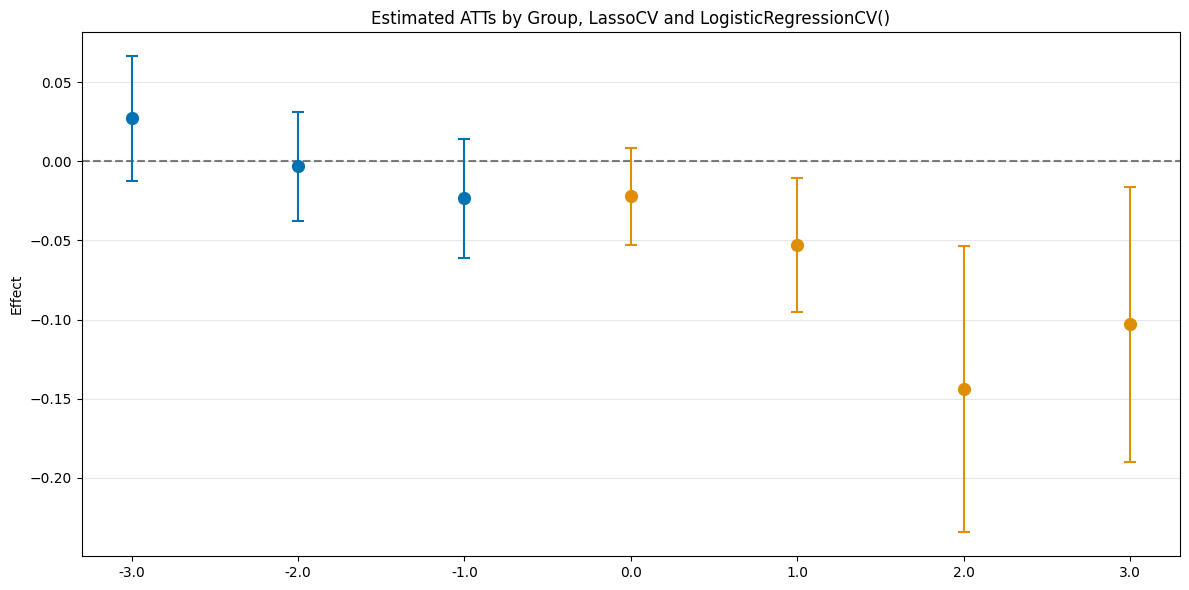

In [19]:
es_rf = dml_obj_lasso.aggregate("eventstudy")
es_rf.aggregated_frameworks.bootstrap()
es_rf.plot_effects(title="Estimated ATTs by Group, LassoCV and LogisticRegressionCV()")